<a href="https://colab.research.google.com/github/BaherIsmail/LinearRegression/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

In [110]:
df=pd.read_csv("Salary_dataset.csv")

In [112]:
df=df.drop(["Unnamed: 0"],axis=1)

In [113]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.413333,76004.000000
std,2.837888,27414.429785
min,1.200000,37732.000000
25%,3.300000,56721.750000
50%,4.800000,65238.000000
75%,7.800000,100545.750000
max,10.600000,122392.000000


In [114]:
#Since no null values , we dont need to use simple imputers to fill the null values with mean , median.
#Also , applying any of these steps should be done after train test split to avoid data leakage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [115]:
df.columns

Index(['YearsExperience', 'Salary'], dtype='object')

Skewness [YearsExperience]:  0.38


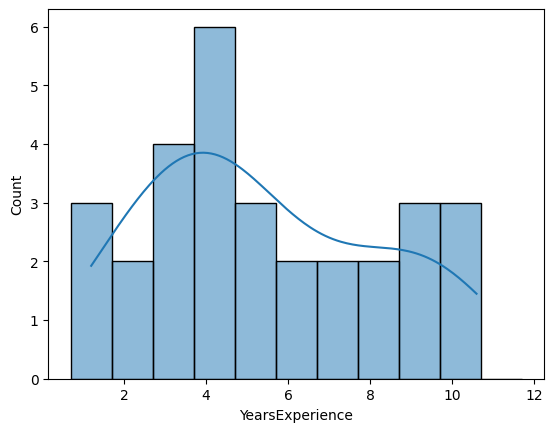

In [116]:
sns.histplot(df["YearsExperience"], discrete=True,kde=True)
print("Skewness [YearsExperience]: ", round(df["YearsExperience"].skew(), 2))


Skewness [Salary]:  0.35


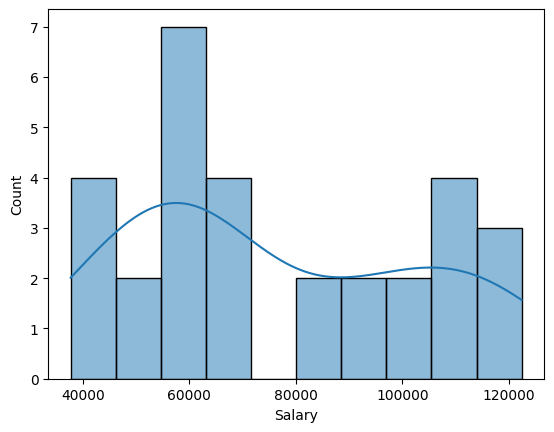

In [117]:
sns.histplot(df["Salary"],bins=10,kde=True)
print("Skewness [Salary]: ", round(df["Salary"].skew(), 2))

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [118]:
X=df["YearsExperience"].values
y=df["Salary"].values

In [119]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [120]:
###INCASE WE NEED STANDARD SCALING

In [121]:
#from sklearn.preprocessing import StandardScaler
#SC=StandardScaler()
#x_train_scaled=SC.fit_transform(X_train)
#x_test_scaled=SC.transform(X_test)

In [128]:
y_train

array([122392., 109432.,  56958.,  39344.,  39892.,  66030.,  56643.,
        57082.,  55795., 101303.,  46206.,  37732., 105583.,  43526.,
        98274., 116970.,  81364., 121873.,  91739.,  54446.,  63219.,
        61112.,  93941.,  60151.])

In [122]:
lr=LinearRegression()

In [130]:
lr.fit(X_train.reshape(-1,1),y_train.reshape(-1,1))

LinearRegression()

In [132]:
lr.score(X_train.reshape(-1,1),y_train.reshape(-1,1))

0.9645401573418148

In [134]:
y_pred = lr.predict(X_test.reshape(-1,1))

In [136]:
#Evaluate: compare predictions with the real answers
print("MAE :", mean_absolute_error(y_test.reshape(-1,1), y_pred.reshape(-1,1)))
print("RMSE:", np.sqrt(mean_squared_error(y_test.reshape(-1,1), y_pred.reshape(-1,1))))
print("R²  :", r2_score(y_test.reshape(-1,1), y_pred.reshape(-1,1)))
print("#"*50)
#Check overfitting: train score vs test score
print("Train R²:", lr.score(X_train.reshape(-1,1), y_train.reshape(-1,1)))
print("Test  R²:", lr.score(X_test.reshape(-1,1), y_test.reshape(-1,1)))


MAE : 6286.453830757745
RMSE: 7059.04362190151
R²  : 0.9024461774180497
##################################################
Train R²: 0.9645401573418148
Test  R²: 0.9024461774180497


In [165]:
data=pd.DataFrame({"X_Test": X_test, "Y_Test": y_test, "Y_Pred": y_pred.flatten(),"Y^":y_test-y_pred.flatten()})

In [171]:
print("MAE :", data["Y^"].abs().mean())

MAE : 6286.453830757745


In [172]:
data

,X_Test,Y_Test,Y_Pred,Y^
0,9.7,112636.0,115791.210113,-3155.210113
1,5.0,67939.0,71499.278095,-3560.278095
2,8.3,113813.0,102597.868661,11215.131339
3,5.4,83089.0,75268.804224,7820.195776
4,3.3,64446.0,55478.792045,8967.207955
5,3.8,57190.0,60190.699707,-3000.699707
